# Exercise 2

The goal of the exercise is to implement the MPPI algorithm discussed in class to control a (simplified) 3 degrees of freedom manipulator.

You do not have access to the dynamics of the manipulator but only to a simulator (the ``simulate`` function) which you can use to test how the manipulator would behave for a given control sequence.
* The states $x$ of the manipulator are the angles (in radians) of the 3 joints.
* The controls $u$ set the velocity of the joints (3 controls).
* The tip of the manipulator is $p(x)$ and depends on the current states $x$ (this is computed using a ``forward_kinematics`` function).
* We assume a single shooting problem where we only optimize the control sequence $\bar{u} = u_0,u_1,\cdots$ and compute the resulting states using the simulator

The goal is to get the manipulator's tip $p(x)$ to reach a desired goal position by minimizing (with respect to $\bar{u}$)
$$l(\bar{u}) = \sum_{n=0}^{N_{horizon}} (p(x_n) - p_{desired})^2 + 0.01 u_n^2$$

To do so, you will implement a model-predictive controller using the MPPI algorithm in its inner loop.

## MPPI algorithm
At each iteration, the MPPI algorithm computes an improved control through
$$\bar{u} \leftarrow \bar{u} - \alpha \frac{ - \lambda \mathbb E \left[  \exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon) \right) \Sigma^{-1}  \epsilon \right]}{ \mu \mathbb   E \left[ \exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon) \right) \right]  }$$

which is approximated through Monte-Carlo sampling by
$$\bar{u} \leftarrow \bar{u} - \alpha \frac{ - \lambda \mathbb \sum_{k=1}^K \left(\exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon_k) \right) \Sigma^{-1}  \epsilon_k \right)}{ \mu \mathbb   \sum_{k=1}^K \left( \exp\left(- \frac{1}{\lambda} l(\bar{u} + \mu \epsilon_k) \right) \right)  }$$


Tips to implement the algorithm:
* The parameters $\alpha = 1$, $\Sigma = I$, $\lambda=0.1$, $\mu=2$ and $K=50$ work well for this problem (use the same samples to evaluate both sums)
* Do only one update of $\bar{u}$ per control cycle (i.e. one descent step) and reuse the previous trajectory as an initial guess shifted by one time-step (for the warm start)
* Use $N_{horizon} = 10$ (optimize 10 time steps ahead)
* Use the numpy function ``random.multivariate_normal`` to draw a random sample from a multi-dimensional Gaussian distribution (you will need to draw $3N_{horizon}$ samples for $\epsilon$)

## Questions
1. Implement the MPPI algorithm and use it to reach the following positions $(2,1)$, $(2,2)$, $(1,-2)$ (one full run per position). Run the simulation for 500 time steps.
2. How does the algorithm perform across different runs? Do you always get the same result? Why?
3. Plot the average cost and its variance across 10 runs for each target position

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import manipulator

In [2]:
## the manipulator package contains all the necessary functions to simulate the robot

## the forward_kinematics function returns the position of the tip of the manipulator as a function of the joint positions
joint_position = np.array([0.,0.,0.])
tip_position = manipulator.forward_kinematics(joint_position)
print(f'the tip of the manipulator is at x={tip_position[0]:0.1f}, y={tip_position[1]:0.1f} ' + \
      f'when the joints are at {joint_position[0]:0.1f}, {joint_position[2]:0.1f}, {joint_position[2]:0.1f}')

joint_position = np.array([0.5,0.5,0.5])
tip_position = manipulator.forward_kinematics(joint_position)
print(f'the tip of the manipulator is at x={tip_position[0]:0.1f}, y={tip_position[1]:0.1f} ' + \
      f'when the joints are at {joint_position[0]:0.1f}, {joint_position[2]:0.1f}, {joint_position[2]:0.1f}')

the tip of the manipulator is at x=2.4, y=0.0 when the joints are at 0.0, 0.0, 0.0
the tip of the manipulator is at x=1.4, y=1.8 when the joints are at 0.5, 0.5, 0.5


In [3]:
## the manipulator can be simulated with a control trajectory of length N

## the simulate function returns the time, state trajectory [3,N] and control trajectory [3,N]

N = 500 #number of timesteps
initial_state = np.array([0.,0.,0.])

## we compute a random control trajectory drawn from a multivariate normal distribution
u = np.reshape(np.random.multivariate_normal(np.zeros(3*N), np.eye(3*N)),[3,N])
t,x, u = manipulator.simulate(initial_state, u, N)

## the states can be displayed using the animate_robot function as follows
manipulator.animate_robot(x)

Your browser does not support the video tag.

## Part 1

In [14]:
class MPPI_controller:
    def __init__(self, manipulator, p_desired=np.array([0, 0]), n_x=3, n_u=3, n_p=2, T=10, alpha=1.0, sigma=None, temp=0.1, mu=2.0, K=50, seed=0):
        self.manipulator = manipulator
        self.n_x = n_x
        self.n_u = n_u
        self.n_p = n_p
        self.T = T
        self.alpha = alpha
        self.sigma = np.eye(n_u) if sigma is None else sigma
        self.temp = temp
        self.mu = mu
        self.K = K

        np.random.seed(seed)

        self.U = np.zeros((self.n_u, self.T))
        self.p_desired = p_desired

        self.cost_history = []

    def p(self, x):
        return self.manipulator.forward_kinematics(x)

    def loss_function(self, X, V):
        P_error = np.zeros((self.K, self.n_p, self.T + 1))
        for k in range(self.K):
            for t in range(self.T + 1):
                P_error[k, :, t] = self.p(X[k, :, t]) - self.p_desired
                
        position_loss = np.sum(P_error ** 2, axis=(1, 2))
        control_loss = 0.01 * np.sum(V ** 2, axis=(1, 2))

        J = position_loss + control_loss
        return J

    def __call__(self, states):
        x0 = states[-1].copy() if isinstance(states, np.ndarray) and states.ndim > 1 else states.copy()

        epsilon = np.random.multivariate_normal(
            mean=np.zeros(self.n_u * self.T),
            cov=np.eye(self.n_u * self.T),
            size=self.K
        )
        epsilon = np.reshape(epsilon, [self.K, self.n_u, self.T])

        V = self.U + self.mu * epsilon

        X = np.zeros((self.K, self.n_x, self.T + 1))
        for k in range(self.K):
            _, x, _ = self.manipulator.simulate(x0, V[k], self.T)
            X[k] = x

        J = self.loss_function(X, V)
        rho = np.min(J)
        S = np.exp(-(J - rho) / self.temp)

        self.cost_history.append(rho)

        numerator = np.zeros((self.n_u, self.T))
        for k in range(self.K):
            numerator += S[k] * np.linalg.inv(self.sigma) @ epsilon[k]
        numerator = -self.temp * numerator

        denominator = self.mu * np.sum(S)
        gradient = numerator / denominator

        U_star = self.U - self.alpha * gradient

        self.U = np.hstack([U_star[:, 1:], np.zeros((self.n_u, 1))])

        return U_star[:, 0]        

    def reset(self):
        self.U = np.zeros((self.n_u, self.T))
        self.cost_history = []

### Position 1

In [13]:
## fill in the controller function
#def controller(states):
#    ''' simplistic MPC loop '''
#    Nhorizon = 10
#    u_guess = np.reshape(np.random.multivariate_normal(np.zeros(3*Nhorizon), np.eye(3*Nhorizon)),[3,Nhorizon])
#    
#    return u_guess[:,0]

controller = MPPI_controller(manipulator, p_desired = np.array([2, 1]))

## run the MPC controller
N_timesteps = 500
t, states, control = manipulator.simulate(np.zeros([3,]), controller, N_timesteps)

## display the results
manipulator.animate_robot(states)

## Note that the simulate function can take either a control trajectory of size [3,N] 
## or a function f(states) that will be called at each control cycle (cf. examples above)

Your browser does not support the video tag.

### Position 2

In [6]:
controller = MPPI_controller(manipulator, p_desired = np.array([2, 2]))

## run the MPC controller
N_timesteps = 500
t, states, control = manipulator.simulate(np.zeros([3,]), controller, N_timesteps)

## display the results
manipulator.animate_robot(states)

Your browser does not support the video tag.

### Position 3

In [7]:
controller = MPPI_controller(manipulator, p_desired = np.array([1, -2]))

## run the MPC controller
N_timesteps = 500
t, states, control = manipulator.simulate(np.zeros([3,]), controller, N_timesteps)

## display the results
manipulator.animate_robot(states)

Your browser does not support the video tag.

## Part 2
the algorithm performs the same across different runs since the given seed (0) for np.random is the same across the runs. 

## Part 3
note: new seed is given each run

In [8]:
def run_episode(manipulator, target, seed, N=500):
    c = MPPI_controller(manipulator, p_desired=np.array(target, float), seed=seed)
    manipulator.simulate(np.zeros(3), c, N)
    return np.array(c.cost_history, float)

def gather(manipulator, targets, N_runs=10, N=500, base_seed=0):
    res = {}
    for ti, target in enumerate(targets):
        runs = []
        for r in range(N_runs):
            runs.append(run_episode(manipulator, target, base_seed + 1000*ti + r))
        res[tuple(target)] = runs
    return res

def plot_vsrun(res, title1="Average cost vs run", title2="Variance vs run"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True)
    for target, runs in res.items():
        avg_per_run = [np.mean(h) if len(h)>0 else np.nan for h in runs]
        var_per_run = [np.var(h) if len(h)>0 else np.nan for h in runs]
        x = np.arange(len(avg_per_run))
        ax1.plot(x, avg_per_run, marker='o', label=f"{np.array(target)}")
        ax2.plot(x, var_per_run, marker='o', label=f"{np.array(target)}")
    ax1.set_ylabel("Average ρ per run"); ax1.set_title(title1); ax1.grid(True, alpha=0.3)
    ax2.set_ylabel("Variance ρ per run"); ax2.set_title(title2); ax2.set_xlabel("Run index"); ax2.grid(True, alpha=0.3)
    ax1.legend(title="Target")
    plt.tight_layout(); plt.show()

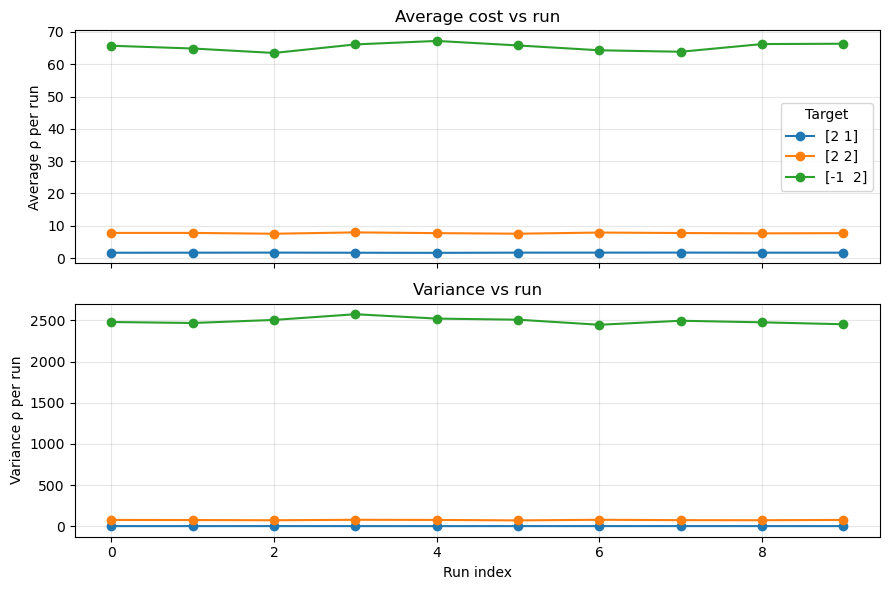

In [9]:
targets = [(2,1), (2,2), (-1,2)]

res = gather(manipulator, targets, N_runs=10, N=500)
plot_vsrun(res)